# RT-DETR — Construction Site Safety Detection

**Model:** RT-DETR (transformer-based real-time detector (2023))
**Task:** Object detection — 3 classes: helmet, vest, head

---

## 1. Install & Import

In [1]:
!pip install -q ultralytics opencv-python-headless seaborn

In [2]:
%matplotlib inline
import os
import gc
import json
import glob
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import RTDETR

plt.rcParams['figure.dpi'] = 100

## 2. Configuration

In [ ]:
DATASET_ROOT = 'C:/Users/AIPC/anaconda_projects/assignment 3/project/dataset'

BASE_DIR = os.path.abspath(os.path.dirname(DATASET_ROOT.rstrip('/')))
IMAGES_DIR = os.path.join(DATASET_ROOT, 'images')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output_rtdetr')
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ['helmet', 'vest', 'head']
NUM_CLASSES = 3
IMG_SIZE = 832
EPOCHS   = 60
PATIENCE = 12

RUN_DIR     = os.path.join(OUTPUT_DIR, 'train')
WEIGHTS_DIR = os.path.join(RUN_DIR, 'weights')
BEST_PT     = os.path.join(WEIGHTS_DIR, 'best.pt')
RESUME_LOG  = os.path.join(OUTPUT_DIR, 'resume_log.txt')
STATUS_FILE = os.path.join(OUTPUT_DIR, 'status.json') 

print('Kernel working dir :', os.getcwd())
print('OUTPUT_DIR         :', OUTPUT_DIR)
print('Dataset            :', DATASET_ROOT)

Kernel working dir : C:\Users\AIPC\anaconda_projects\assignment 3\project\notebooks
OUTPUT_DIR         : C:\Users\AIPC\anaconda_projects\assignment 3\project\output_rtdetr
Dataset            : C:/Users/AIPC/anaconda_projects/assignment 3/project/dataset


## 3. Status Tracking + Helpers

In [ ]:
def load_status():
    if os.path.exists(STATUS_FILE):
        with open(STATUS_FILE) as f:
            return json.load(f)
    return {'trained': False, 'evaluated': False}

def save_status(status):
    with open(STATUS_FILE, 'w') as f:
        json.dump(status, f, indent=2)

def log_event(msg):
    stamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{stamp}] {msg}'
    with open(RESUME_LOG, 'a') as f:
        f.write(line + '\n')
    print(line)

def free_memory(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


status = load_status()
print('Current status:', status)

Current status: {'trained': True, 'evaluated': False}


## 4. Write dataset YAML

In [5]:
yaml_text = (
    f"path: {DATASET_ROOT}\n"
    f"train: images/train\nval: images/val\ntest: images/test\n"
    f"nc: {NUM_CLASSES}\nnames: {CLASS_NAMES}\n"
)
DATA_YAML = os.path.join(OUTPUT_DIR, 'data_3class.yaml')
with open(DATA_YAML, 'w') as f:
    f.write(yaml_text)
print('Wrote', DATA_YAML)

Wrote C:\Users\AIPC\anaconda_projects\assignment 3\project\output_rtdetr\data_3class.yaml


## Phase 1 — Train RT-DETR

In [ ]:
import glob, re

def newest_epoch_ckpt():
    cks = glob.glob(os.path.join(WEIGHTS_DIR, 'epoch*.pt'))
    best_n, best_p = -1, None
    for p in cks:
        m = re.search(r'epoch(\d+)\.pt$', os.path.basename(p))
        if m:
            n = int(m.group(1))
            if n > best_n:
                best_n, best_p = n, p
    return best_p, best_n

def assert_3class(model):
    nc = None
    try:
        if hasattr(model, 'model') and hasattr(model.model, 'yaml'):
            nc = model.model.yaml.get('nc', None)
    except Exception:
        nc = None
    if nc is None:
        try:
            nc = model.model.model[-1].nc        
        except Exception:
            nc = None
    if nc is None:
        print('WARNING: could not read nc from checkpoint to verify it is '
              '3-class; relying on explicit data=DATA_YAML instead.')
        return
    assert nc == NUM_CLASSES, (
        f'Loaded checkpoint has nc={nc}, expected {NUM_CLASSES}. '
        f'Refusing to train — this is NOT our construction model.')

if status.get('trained'):
    log_event('Phase 1 SKIPPED — training already completed previously '
              '(status.trained=True).')
else:
    ckpt_path, ckpt_epoch = newest_epoch_ckpt()

    if ckpt_path is not None:
        # ---- WARM-RESTART RESUME ----
        log_event(f'Phase 1 RESUME — found {os.path.basename(ckpt_path)} '
                  f'(epoch {ckpt_epoch}). Continuing, EXPLICIT data=, '
                  f'no resume=True.')
        model = RTDETR(ckpt_path)             
        assert_3class(model)                
        remaining = max(EPOCHS - ckpt_epoch, 1)
        log_event(f'   {ckpt_epoch} epochs done, training {remaining} '
                  f'more (target {EPOCHS}).')
        model.train(
            data=DATA_YAML, imgsz=IMG_SIZE, epochs=remaining, batch=8,   
            patience=PATIENCE, optimizer='auto',
            project=OUTPUT_DIR, name='train', exist_ok=True,
            plots=True, verbose=True, save_period=1, val=False,
            workers=0,  
        )
    else:
        # ---- FRESH START ----
        log_event('Phase 1 FRESH START — COCO-pretrained, EXPLICIT '
                  'data=DATA_YAML (cannot fall back to coco8).')
        model = RTDETR('rtdetr-l.pt')
        model.train(
            data=DATA_YAML, imgsz=IMG_SIZE, epochs=EPOCHS, batch=8,   
            patience=PATIENCE, optimizer='auto',
            project=OUTPUT_DIR, name='train', exist_ok=True,
            plots=True, verbose=True, save_period=1, val=False,
            workers=0,  
        )

    assert os.path.exists(BEST_PT), 'best.pt not created — training failed.'
    status['trained'] = True
    save_status(status)
    log_event('Phase 1 COMPLETE — training finished, status saved.')
    free_memory(model)
    log_event('Memory freed after training.')

print('Phase 1 state: trained =', load_status()['trained'])
print('best.pt exists:', os.path.exists(BEST_PT))

[2026-05-20 18:57:43] Phase 1 SKIPPED — training already completed previously (status.trained=True).
Phase 1 state: trained = True
best.pt exists: True


## 4b. Resume / Phase Log 

In [7]:
if os.path.exists(RESUME_LOG):
    print('===== RESUME / PHASE LOG =====')
    print(open(RESUME_LOG).read())
else:
    print('No log yet.')

===== RESUME / PHASE LOG =====
[2026-05-19 17:39:35] Phase 1 FRESH START — COCO-pretrained, EXPLICIT data=DATA_YAML (cannot fall back to coco8).
[2026-05-20 10:57:08] Phase 1 COMPLETE — training finished, status saved.
[2026-05-20 10:57:08] Memory freed after training.
[2026-05-20 18:44:27] Phase 1 SKIPPED — training already completed previously (status.trained=True).
[2026-05-20 18:45:52] Phase 1 SKIPPED — training already completed previously (status.trained=True).
[2026-05-20 18:49:01] Phase 1 SKIPPED — training already completed previously (status.trained=True).
[2026-05-20 18:52:16] Phase 1 SKIPPED — training already completed previously (status.trained=True).
[2026-05-20 18:57:43] Phase 1 SKIPPED — training already completed previously (status.trained=True).



## Phase 2 — Evaluate (Train / Val / Test)

In [ ]:
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')

if status.get('evaluated') and os.path.exists(metrics_path):
    log_event('Phase 2 SKIPPED — evaluation already done. Loading saved metrics.')
    with open(metrics_path) as f:
        metrics = json.load(f)
else:
    assert os.path.exists(BEST_PT), (
        f'besst.pt not found at {BEST_PT}. Training may not have finished.')
    eval_model = RTDETR(BEST_PT)               
    metrics = {}
    for split in ['train', 'val', 'test']:
        m = eval_model.val(data=DATA_YAML, imgsz=IMG_SIZE,
                            split=split, verbose=False, workers=0)
        metrics[split] = {
            'mAP@0.5':      float(m.box.map50),
            'mAP@0.5:0.95': float(m.box.map),
            'precision':    float(m.box.mp),
            'recall':       float(m.box.mr),
            'per_class_AP@0.5': {
                CLASS_NAMES[i]: float(m.box.ap50[i])
                for i in range(len(CLASS_NAMES)) if i < len(m.box.ap50)
            },
        }
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)
    status['evaluated'] = True
    save_status(status)
    log_event('Phase 2 COMPLETE — metrics saved.')
    free_memory(eval_model)


print('=' * 68)
print(f"{'Split':<10}{'mAP@0.5':>12}{'mAP@.5:.95':>14}{'Precision':>12}{'Recall':>10}")
print('-' * 68)
for split in ['train', 'val', 'test']:
    r = metrics[split]
    print(f"{split:<10}{r['mAP@0.5']:>12.4f}{r['mAP@0.5:0.95']:>14.4f}"
          f"{r['precision']:>12.4f}{r['recall']:>10.4f}")
print('=' * 68)
print('\nPer-class AP@0.5 (TEST):')
for cls, ap in metrics['test']['per_class_AP@0.5'].items():
    print(f"  {cls:<8}: {ap:.4f}")

Ultralytics 8.4.41  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 232.970.0 MB/s, size: 231.9 KB)
val: Scanning C:\Users\AIPC\anaconda_projects\assignment 3\project\dataset\labels\train.cache... 17248 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17248/17248 1.9Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1078/1078 3.8it/s 4:41<0.3s
                   all      17248     148487      0.933      0.941      0.958      0.641
Speed: 0.4ms preprocess, 5.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\AIPC\anaconda_projects\assignment 3\project\notebooks\runs\detect\val-6
Ultralytics 8.4.41  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradi

## Phase 3 — Visualizations

Curves, confusion matrix, correct/incorrect examples.

### 3a. Training Curves

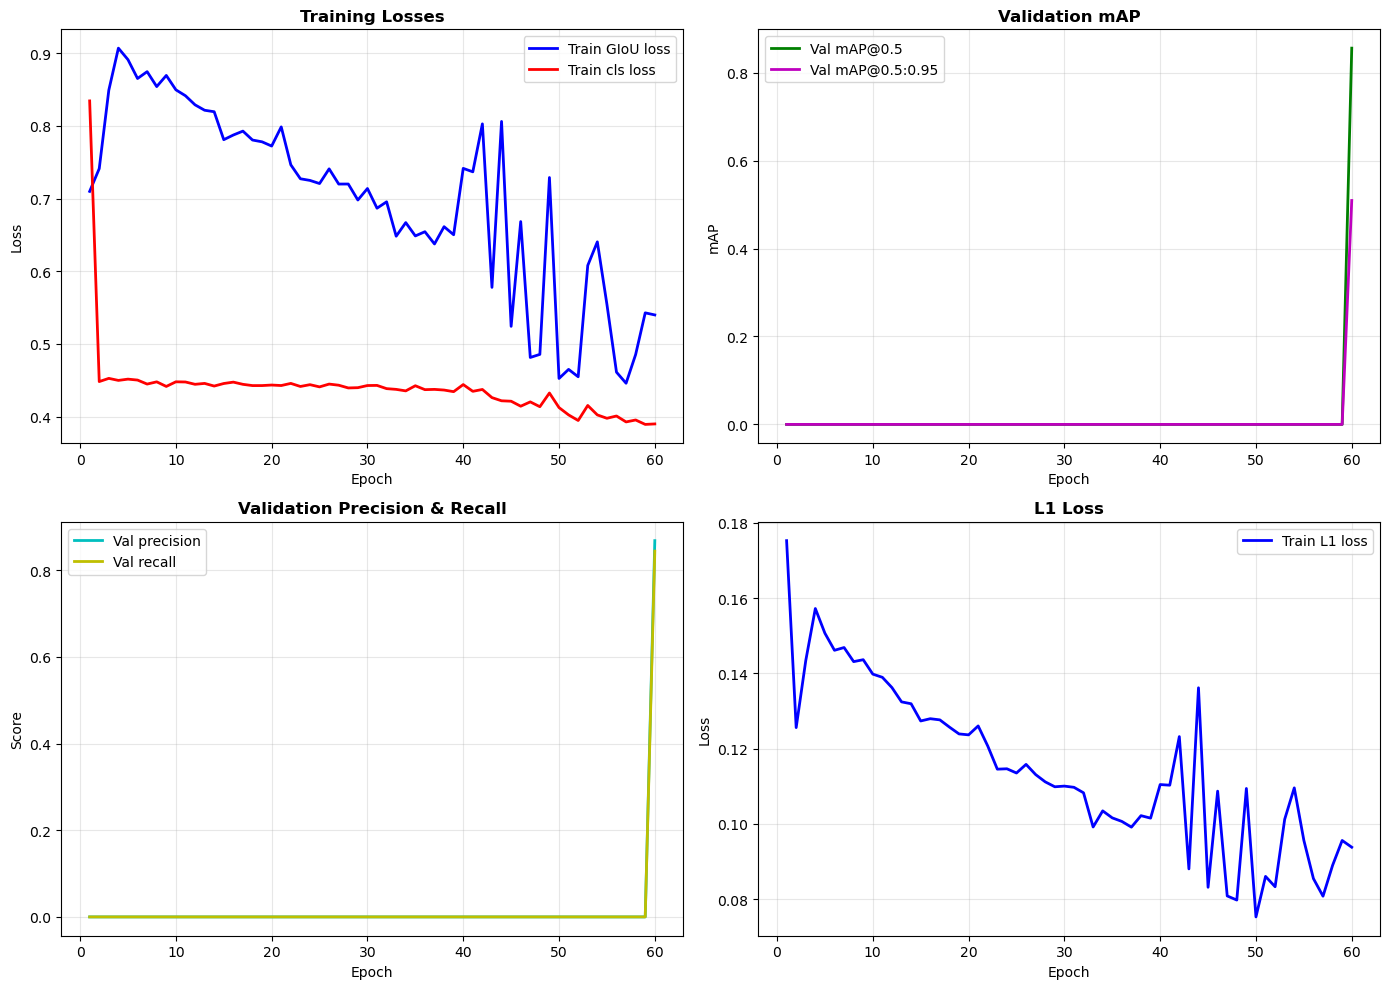

In [ ]:
df = pd.read_csv(os.path.join(RUN_DIR, 'results.csv'))
df.columns = df.columns.str.strip()
ep = df['epoch']

is_rtdetr = 'train/giou_loss' in df.columns
loss1_col = 'train/giou_loss' if is_rtdetr else 'train/box_loss'
loss1_label = 'Train GIoU loss' if is_rtdetr else 'Train box loss'
loss3_col = 'train/l1_loss' if is_rtdetr else 'train/dfl_loss'
loss3_label = 'Train L1 loss' if is_rtdetr else 'Train DFL loss'
loss3_title = 'L1 Loss' if is_rtdetr else 'DFL Loss'

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax[0,0].plot(ep, df[loss1_col], 'b-', label=loss1_label, linewidth=2)
ax[0,0].plot(ep, df['train/cls_loss'], 'r-', label='Train cls loss', linewidth=2)
ax[0,0].set_title('Training Losses', fontsize=12, fontweight='bold')
ax[0,0].set_xlabel('Epoch'); ax[0,0].set_ylabel('Loss')
ax[0,0].legend(); ax[0,0].grid(True, alpha=0.3)

ax[0,1].plot(ep, df['metrics/mAP50(B)'], 'g-', label='Val mAP@0.5', linewidth=2)
ax[0,1].plot(ep, df['metrics/mAP50-95(B)'], 'm-', label='Val mAP@0.5:0.95', linewidth=2)
ax[0,1].set_title('Validation mAP', fontsize=12, fontweight='bold')
ax[0,1].set_xlabel('Epoch'); ax[0,1].set_ylabel('mAP')
ax[0,1].legend(); ax[0,1].grid(True, alpha=0.3)

ax[1,0].plot(ep, df['metrics/precision(B)'], 'c-', label='Val precision', linewidth=2)
ax[1,0].plot(ep, df['metrics/recall(B)'], 'y-', label='Val recall', linewidth=2)
ax[1,0].set_title('Validation Precision & Recall', fontsize=12, fontweight='bold')
ax[1,0].set_xlabel('Epoch'); ax[1,0].set_ylabel('Score')
ax[1,0].legend(); ax[1,0].grid(True, alpha=0.3)

if loss3_col in df.columns:
    ax[1,1].plot(ep, df[loss3_col], 'b-', label=loss3_label, linewidth=2)
    ax[1,1].set_title(loss3_title, fontsize=12, fontweight='bold')
    ax[1,1].set_xlabel('Epoch'); ax[1,1].set_ylabel('Loss')
    ax[1,1].legend(); ax[1,1].grid(True, alpha=0.3)
else:
    ax[1,1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### 3b. Confusion Matrix (Test Set)

Ultralytics 8.4.41  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1003.8304.6 MB/s, size: 120.2 KB)
val: Scanning C:\Users\AIPC\anaconda_projects\assignment 3\project\dataset\labels\test.cache... 2455 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2455/2455 792.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 3.9it/s 39.0s0.2ss
                   all       2455      20193      0.873      0.843      0.867      0.518
                helmet       1822       6749      0.945      0.889      0.911      0.605
                  vest        440        935      0.826      0.787      0.845      0.561
                  head        713      12509      0.849      0.851      0.847      0.386
Speed: 0.4ms preprocess, 5.5ms inference, 0.0ms loss, 0.4ms postprocess 

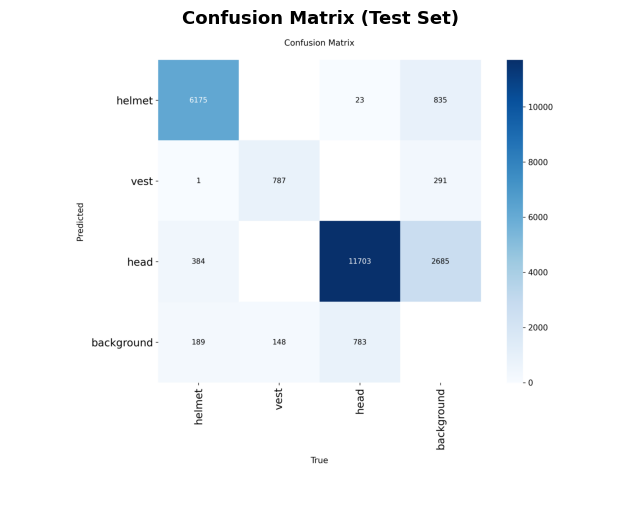

In [ ]:
cm_model = RTDETR(BEST_PT)           
cm_model.val(data=DATA_YAML, imgsz=IMG_SIZE, split='test',
                      plots=True, project=OUTPUT_DIR, name='test_eval', exist_ok=True,
                      workers=0)
cm_path = os.path.join(OUTPUT_DIR, 'test_eval', 'confusion_matrix.png')
if os.path.exists(cm_path):
    plt.figure(figsize=(8, 7))
    plt.imshow(Image.open(cm_path)); plt.axis('off')
    plt.title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
free_memory(cm_model)
plt.show()

### 3c. Correct vs Incorrect Detections

Scoring test images:   0%|          | 0/2455 [00:00<?, ?it/s]

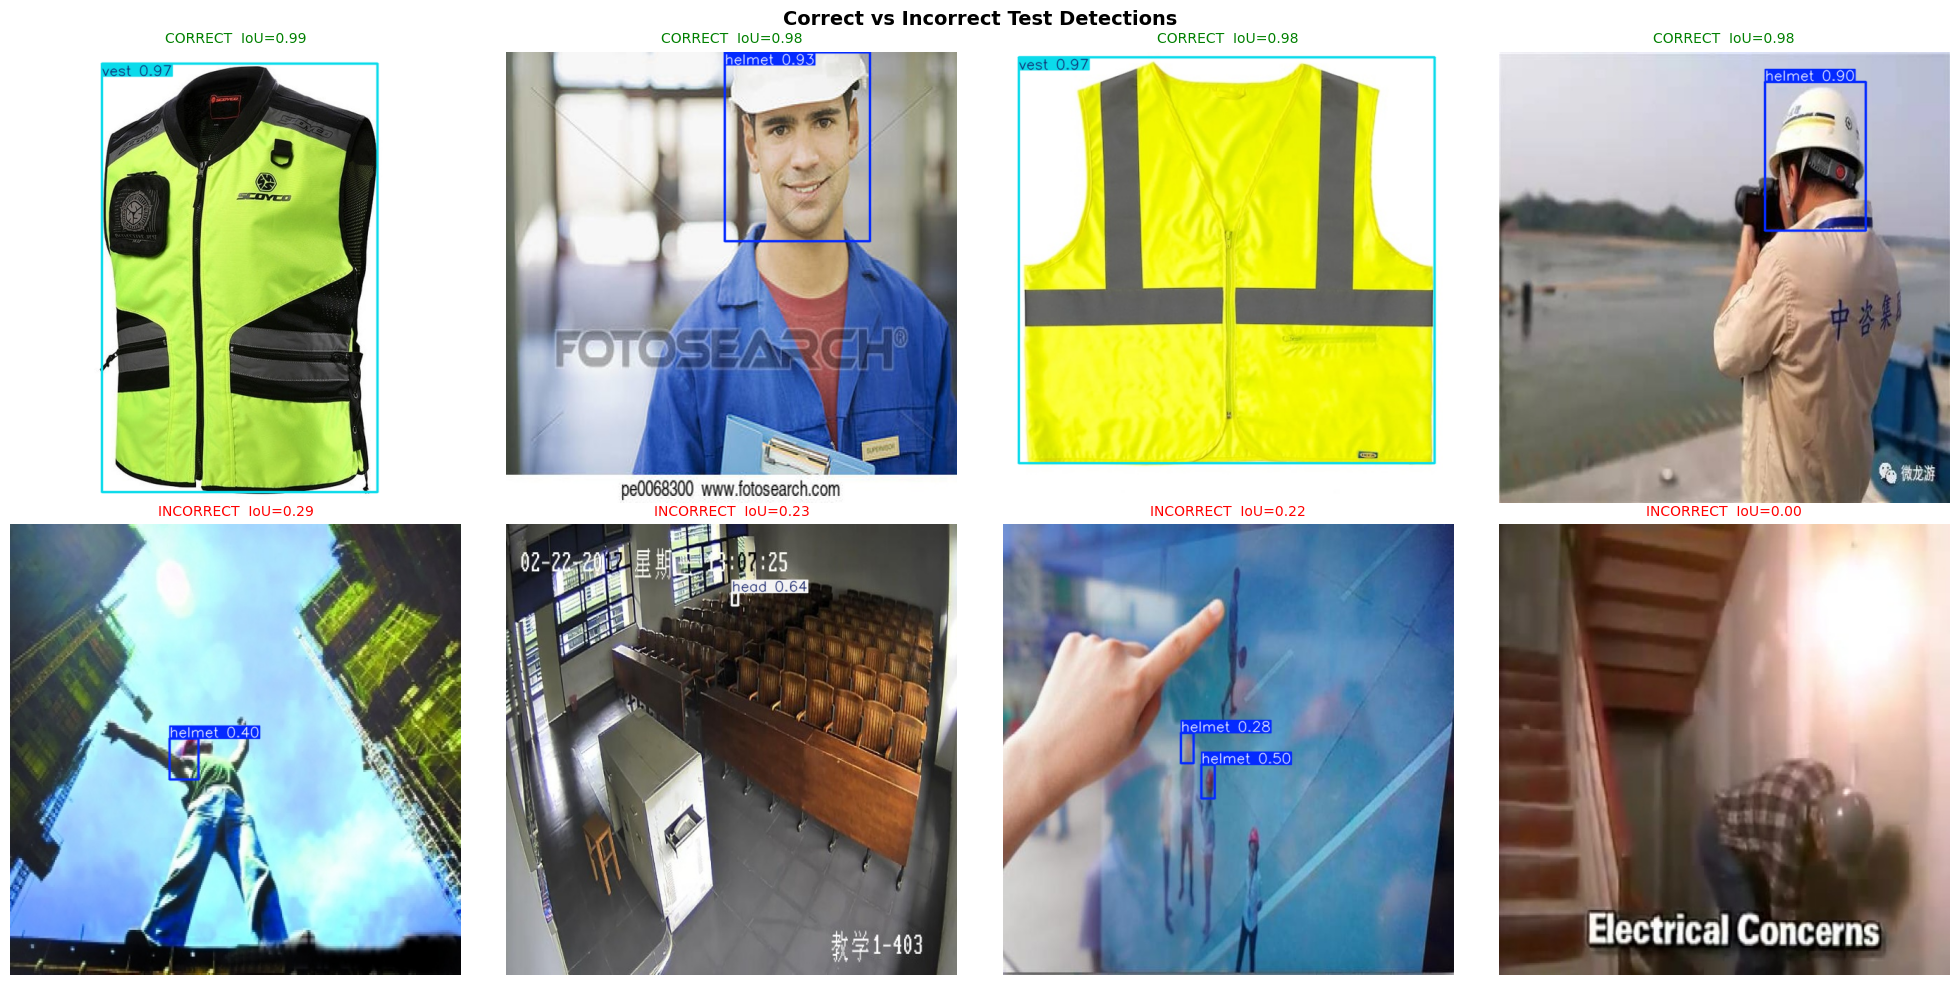

In [12]:
def read_gt_boxes(label_path, img_w, img_h):
    boxes = []
    if os.path.exists(label_path):
        for line in open(label_path):
            parts = line.split()
            if len(parts) != 5:
                continue
            _, cx, cy, bw, bh = parts
            cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)
            boxes.append([(cx-bw/2)*img_w, (cy-bh/2)*img_h,
                          (cx+bw/2)*img_w, (cy+bh/2)*img_h])
    return np.array(boxes)

def iou(a, b):
    xA=max(a[0],b[0]); yA=max(a[1],b[1])
    xB=min(a[2],b[2]); yB=min(a[3],b[3])
    inter=max(0,xB-xA)*max(0,yB-yA)
    union=(a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/union if union>0 else 0.0

vis_model = RTDETR(BEST_PT)          # fresh load
test_img_dir = os.path.join(IMAGES_DIR, 'test')
test_lbl_dir = os.path.join(LABELS_DIR, 'test')
test_files = sorted(os.listdir(test_img_dir))

scores = []
for fn in tqdm(test_files, desc='Scoring test images'):
    stem = os.path.splitext(fn)[0]
    img = Image.open(os.path.join(test_img_dir, fn)); W, H = img.size
    gt = read_gt_boxes(os.path.join(test_lbl_dir, stem + '.txt'), W, H)
    if len(gt) == 0:
        continue
    pred = vis_model(os.path.join(test_img_dir, fn),
                     imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    pb = pred.boxes.xyxy.cpu().numpy() if pred.boxes is not None else np.zeros((0,4))
    mi = 0.0 if len(pb)==0 else float(np.mean(
        [max(iou(g, p) for p in pb) for g in gt]))
    scores.append((fn, mi))

scores.sort(key=lambda x: x[1], reverse=True)
chosen = scores[:4] + scores[-4:]

import cv2
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for i, (fn, sc) in enumerate(chosen):
    pred = vis_model(os.path.join(test_img_dir, fn),
                     imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    ax[i//4, i%4].imshow(cv2.cvtColor(pred.plot(), cv2.COLOR_BGR2RGB))
    tag = 'CORRECT' if i < 4 else 'INCORRECT'
    ax[i//4, i%4].set_title(f"{tag}  IoU={sc:.2f}", fontsize=10,
                            color='green' if i < 4 else 'red')
    ax[i//4, i%4].axis('off')
plt.suptitle('Correct vs Incorrect Test Detections', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correct_vs_incorrect.png'),
            dpi=100, bbox_inches='tight')
plt.show()
free_memory(vis_model)
plt.show()